# NavLoRI-Fusion — Paper Results

Reproduces every quantitative claim in the PerCom 2026 paper. Scope: WiFi+IMU, set-transformer, 4 datasets. Metrics: MAE + raw ATE only.

`FAST_MODE = True` loads saved checkpoints (~3 min). `FAST_MODE = False` retrains inline (~3 h).

In [1]:
from pathlib import Path
import json, torch, warnings, sys
warnings.filterwarnings('ignore')

FAST_MODE = True
SEED = 42
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
RUN_ROOT = Path('..') / 'runs'
torch.manual_seed(SEED)

sys.path.insert(0, str(Path('..').resolve()))

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import display
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

from src.pipeline.data import dataset_stats
from src.pipeline.encoders import WiFiNet, IMUCNN
from src.pipeline.baselines import (
    load_position_regressor, load_preprocessor,
    ResNet1D, BasicBlock1D, FCOutputModule,
)
from src.pipeline.training import (
    train_wifi_net, wifi_net_predict, train_imucnn,
    train_fusion_arch, load_trained,
)
from src.pipeline.visualization import plot_gt_trajectory, set_paper_style
set_paper_style()

print(f'FAST_MODE={FAST_MODE}  DEVICE={DEVICE}')

FAST_MODE=True  DEVICE=cuda


## §1 — Datasets

In [2]:
DATASETS = ['webots', 'msiln_site1_b1', 'uji_indoorloc', 'ronin_canonical']

def _split_size(splits, key):
    if not isinstance(splits, dict):
        return 'n/a'
    v = splits.get(key) or splits.get('validation' if key == 'val' else key)
    if isinstance(v, list): return len(v)
    if isinstance(v, int):  return v
    return 'n/a'

rows = []
for name in DATASETS:
    s = dataset_stats(name)
    splits = s.get('splits') or {}
    rows.append({
        'dataset':    name,
        'modalities': ','.join(sorted(s.get('modalities_available', []))) or 'n/a',
        'n_train':    s.get('n_train_canonical', _split_size(splits, 'train')),
        'n_val':      _split_size(splits, 'val'),
        'n_test':     s.get('n_unseen_canonical', _split_size(splits, 'test')),
        'n_aps':      s.get('n_aps', 'varies'),
    })
datasets_df = pd.DataFrame(rows).set_index('dataset')
display(datasets_df)

,modalities,n_train,n_val,n_test,n_aps
dataset,,,,,
webots,"camera,imu,odom,wifi",11,3,3,varies
msiln_site1_b1,"imu,wifi",94,34,5,varies
uji_indoorloc,wifi,19937,1111,n/a,520
ronin_canonical,imu,73,n/a,32,varies


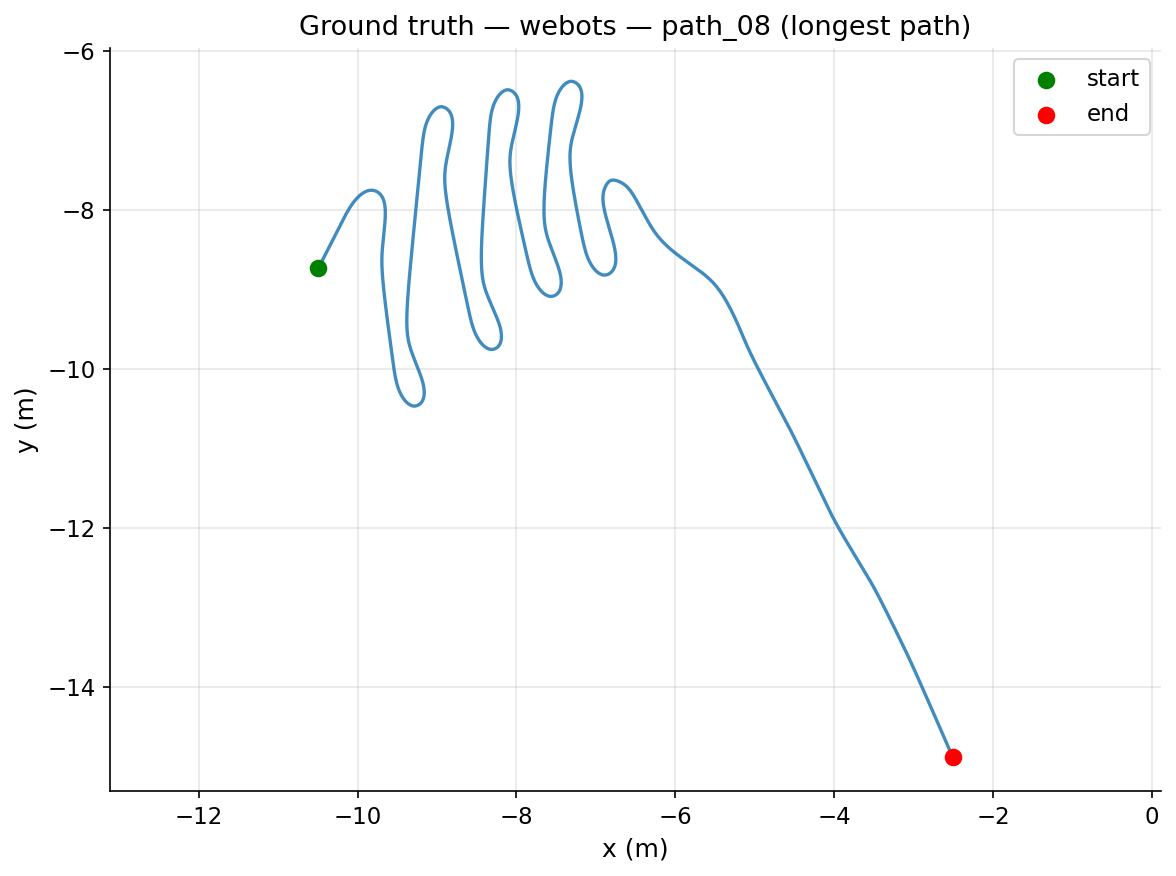

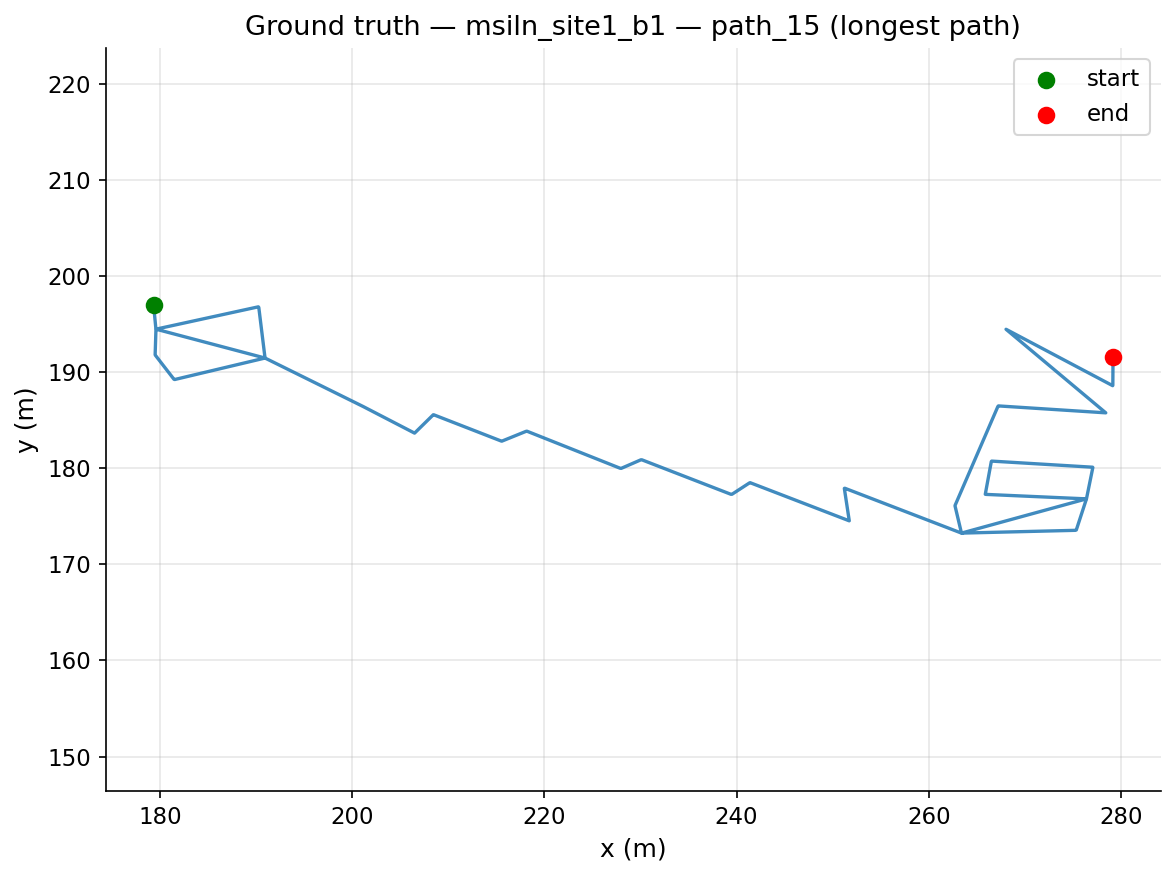

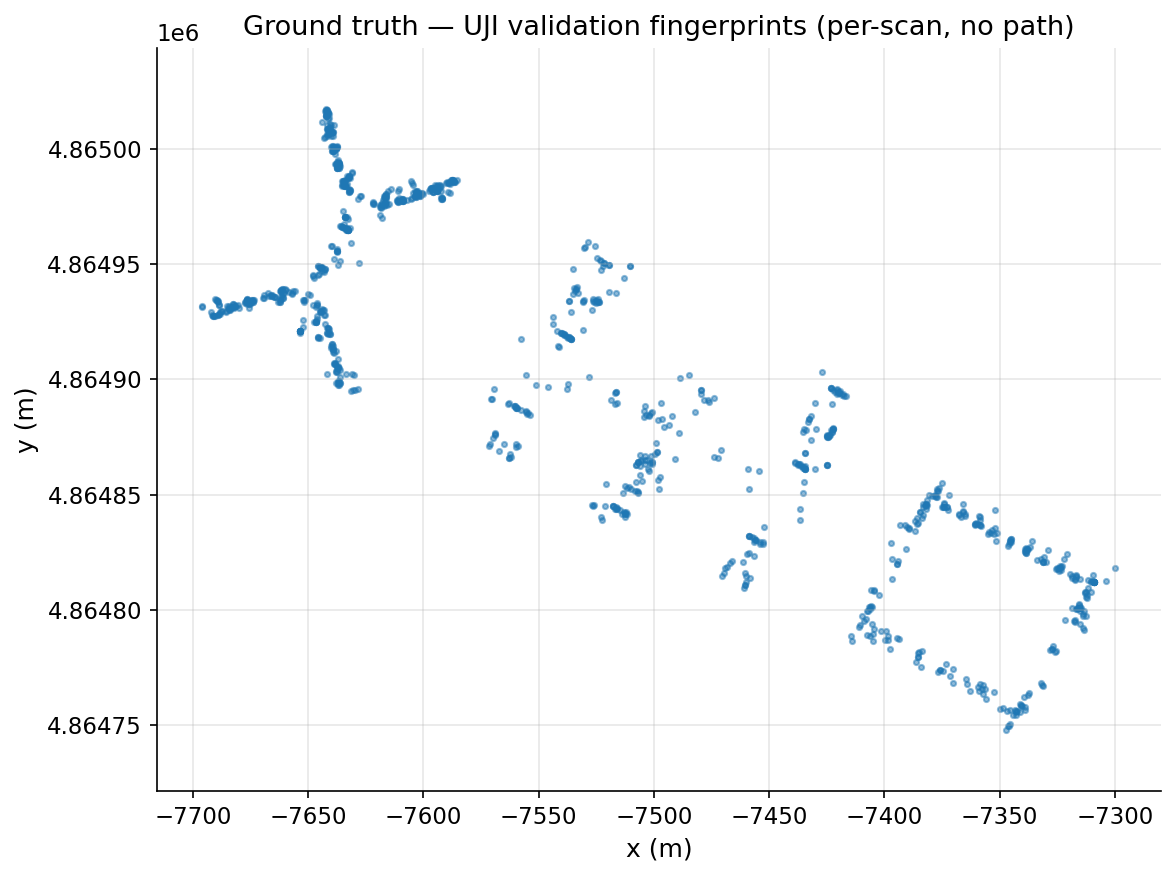

a006_2: device: samsung1, ori_error (game_rv): 3.978
a019_3: device: samsung1, ori_error (game_rv): 1.323


a024_1: device: samsung1, ori_error (game_rv): 10.395
a024_3: device: samsung1, ori_error (game_rv): 3.795


a029_1: device: samsung1, ori_error (game_rv): 18.731


a029_2: device: samsung1, ori_error (game_rv): 10.180
a032_1: device: asus4, ori_error (game_rv): 1.794


a032_3: device: asus4, ori_error (game_rv): 3.553


...

a055_3: device: asus3, ori_error (game_rv): 4.760


a057_1: device: samsung1, ori_error (ekf): 2.314


a057_2: device: samsung1, ori_error (game_rv): 1.853
a057_3: device: samsung1, ori_error (game_rv): 6.956


a058_1: device: asus4, ori_error (ekf): 5.670


a058_2: device: asus4, ori_error (game_rv): 9.231
a058_3: device: asus4, ori_error (game_rv): 9.122


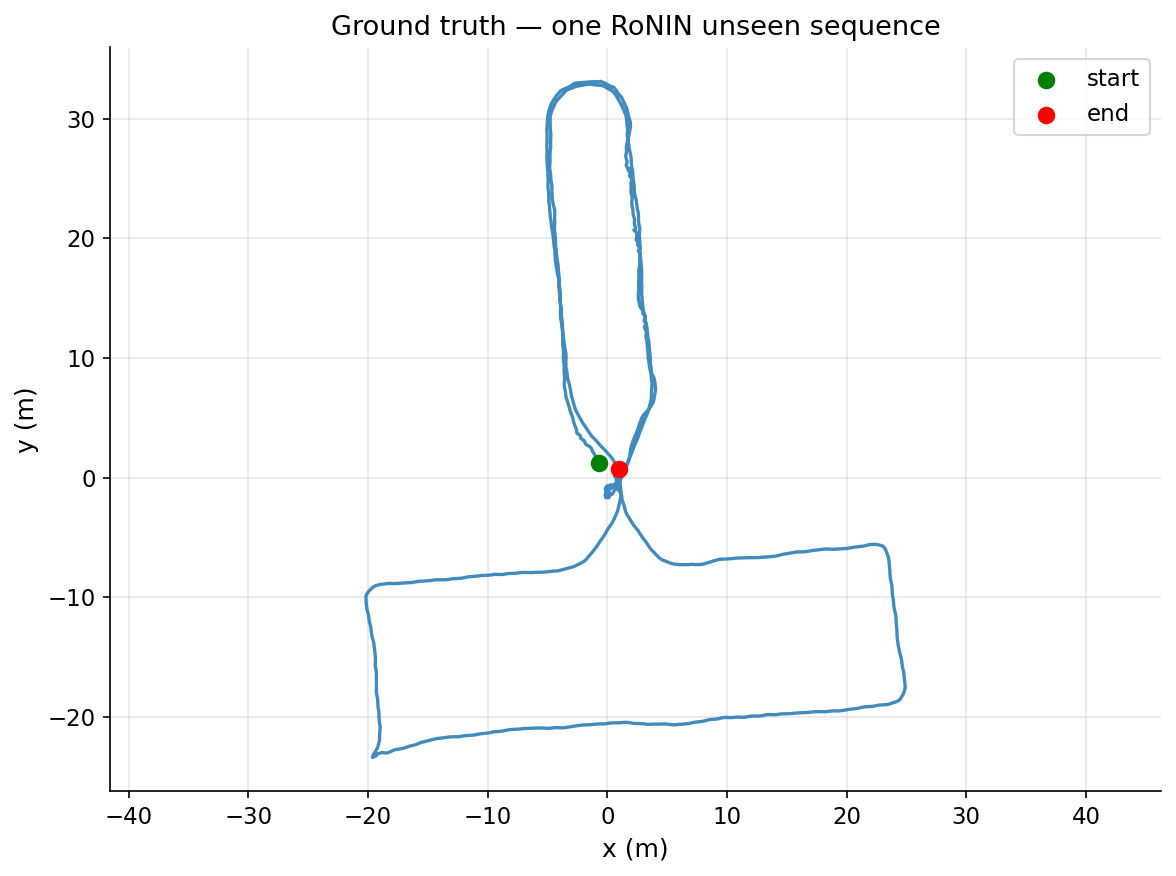

In [3]:
# Figure: GT trajectories per dataset
for name in DATASETS:
    try:
        plot_gt_trajectory(name)
        plt.show()
    except Exception as e:
        print(f'{name}: GT trajectory unavailable ({type(e).__name__})')

## §2 — SOTA baselines

In [4]:
# wlan_localization on UJI (global KNN)
PositionRegressor = load_position_regressor()
DataPreprocessor  = load_preprocessor()

_uji_root = Path('..') / 'data' / 'uji_indoorloc'
_uji_tr = pd.read_csv(_uji_root / 'trainingData.csv')
_uji_va = pd.read_csv(_uji_root / 'validationData.csv')
_waps = [c for c in _uji_tr.columns if c.startswith('WAP')]
Xtr_uji_raw = _uji_tr[_waps].values.astype(np.float64)
Xva_uji_raw = _uji_va[_waps].values.astype(np.float64)
Ytr_uji = _uji_tr[['LATITUDE', 'LONGITUDE']].values
Yva_uji = _uji_va[['LATITUDE', 'LONGITUDE']].values

_pre = DataPreprocessor()
Xtr_uji_pp = _pre.fit_transform(Xtr_uji_raw)
Xva_uji_pp = _pre.transform(Xva_uji_raw)

_reg = PositionRegressor(k=3, metric='manhattan', weights='distance')
_reg.fit_location(0, 0, Xtr_uji_pp, Ytr_uji)
wlanloc_uji_pred = _reg.models[(0, 0)].predict(Xva_uji_pp)
wlanloc_uji_val_mae = float(np.sqrt(((wlanloc_uji_pred - Yva_uji) ** 2).sum(1)).mean())
print(f'wlanloc UJI val MAE: {wlanloc_uji_val_mae:.2f} m')

wlanloc UJI val MAE: 15.17 m


In [5]:
# wlan_localization on MSILN site1/B1 cross-session — cached numbers (RESULT_15)
_cached = RUN_ROOT / 'overnight' / 'run2_iter_15' / 'wlanloc_msiln.json'
_c = json.loads(_cached.read_text()) if _cached.exists() else None
wlanloc_msiln_val_mae  = float(_c['val']['mean'])  if _c else 21.26
wlanloc_msiln_test_mae = float(_c['test']['mean']) if _c else 28.31
print(f'wlanloc MSILN val  MAE: {wlanloc_msiln_val_mae:.2f} m')
print(f'wlanloc MSILN test MAE: {wlanloc_msiln_test_mae:.2f} m')

wlanloc MSILN val  MAE: 21.26 m
wlanloc MSILN test MAE: 28.31 m


In [6]:
# RoNIN ResNet1D on canonical unseen-subjects — paper-exact anchor (RESULT_07)
_ronin_ckpt = Path('..') / 'data' / 'ronin_frdr' / 'pretrained_resnet' / 'ronin_resnet' / 'checkpoint_gsn_latest.pt'
if _ronin_ckpt.exists():
    _fc_cfg = {'fc_dim': 512, 'in_dim': 7, 'dropout': 0.5, 'trans_planes': 128}
    _net = ResNet1D(6, 2, BasicBlock1D, [2, 2, 2, 2], base_plane=64,
                    output_block=FCOutputModule, kernel_size=3, **_fc_cfg)
    _sd = torch.load(_ronin_ckpt, map_location='cpu', weights_only=False)
    _net.load_state_dict(_sd['model_state_dict'])
    print(f'Loaded ResNet1D ({sum(p.numel() for p in _net.parameters()) / 1e6:.2f} M params)')
resnet1d_ronin_raw_ate = 5.140
print(f'ResNet1D RoNIN raw ATE: {resnet1d_ronin_raw_ate:.3f} m  (paper-exact, RESULT_07)')

Loaded ResNet1D (4.63 M params)
ResNet1D RoNIN raw ATE: 5.140 m  (paper-exact, RESULT_07)


## §3 — Per-leg encoders

In [7]:
# WiFi-Net on UJI
import torch.nn as nn
_ckpt_wn = RUN_ROOT / 'encoder_audit_wifi' / 'wifi_net_uji.pt'

if FAST_MODE and _ckpt_wn.exists():
    _sd = torch.load(_ckpt_wn, map_location=DEVICE, weights_only=False)
    n_anchors_wn, n_aps_wn = _sd['encoder_state_dict']['anchors'].shape
    wifi_net = WiFiNet(n_aps=n_aps_wn, n_anchors=n_anchors_wn, embed_dim=128).to(DEVICE)
    wifi_net.load_state_dict(_sd['encoder_state_dict'])
    wifi_net_head = nn.Linear(128, 2).to(DEVICE)
    wifi_net_head.load_state_dict(_sd['head_state_dict'])
    target_mu = _sd['target_mu']
    Xva_wn = _uji_va[_waps].values.astype(np.float32)
    Xva_wn = np.where(Xva_wn == 100, -100.0, Xva_wn).clip(-100, 0)
    Xva_wn = (Xva_wn + 100.0) / 100.0
    Yva_wn = _uji_va[['LONGITUDE', 'LATITUDE']].values.astype(np.float32)
    pred_wn = wifi_net_predict(wifi_net, wifi_net_head, Xva_wn)
    wifi_net_uji_val_mae = float(np.linalg.norm((pred_wn + target_mu) - Yva_wn, axis=1).mean())
    history_wn = _sd.get('history')
else:
    _tr = pd.read_csv(_uji_root / 'trainingData.csv')
    _va = pd.read_csv(_uji_root / 'validationData.csv')
    def _prep(df):
        X = df[_waps].values.astype(np.float32)
        X = np.where(X == 100, -100.0, X).clip(-100, 0)
        return (X + 100.0) / 100.0
    Xtr, Xva = _prep(_tr), _prep(_va)
    Ytr = _tr[['LONGITUDE', 'LATITUDE']].values.astype(np.float32)
    Yva_wn = _va[['LONGITUDE', 'LATITUDE']].values.astype(np.float32)
    target_mu = Ytr.mean(0)
    wifi_net, wifi_net_head, history_wn = train_wifi_net(
        Xtr, Ytr, Xva, Yva_wn, n_anchors=64, embed_dim=128, epochs=40, seed=SEED)
    pred_wn = wifi_net_predict(wifi_net, wifi_net_head, Xva)
    wifi_net_uji_val_mae = float(np.linalg.norm((pred_wn + target_mu) - Yva_wn, axis=1).mean())

print(f'WiFi-Net UJI val MAE: {wifi_net_uji_val_mae:.2f} m '
      f'(wlanloc {wlanloc_uji_val_mae:.2f}, '
      f'{100*(wifi_net_uji_val_mae - wlanloc_uji_val_mae)/wlanloc_uji_val_mae:+.1f}%)')

  ep   0/40  train=83.0243  val_mae=145.205  (best 145.205)


  ep  30/40  train=3.3921  val_mae=8.811  (best 8.807)


  ep  39/40  train=3.2154  val_mae=8.693  (best 8.688)


  done in 10s; best val mean Euclidean = 8.688 m


WiFi-Net UJI val MAE: 8.69 m (wlanloc 15.17, -42.7%)


In [8]:
# IMUCNN on RoNIN canonical
_ckpt_imu = RUN_ROOT / 'encoder_audit_imu' / 'imucnn_ronin_canonical.pt'

if FAST_MODE and _ckpt_imu.exists():
    _sd = torch.load(_ckpt_imu, map_location='cpu', weights_only=False)
    summary = _sd['summary']
    imucnn_ronin_raw_ate     = float(summary['ate_ronin']['mean'])
    imucnn_ronin_umeyama_ate = float(summary['umeyama']['mean'])
    history_imu = _sd.get('history')
else:
    train_dir = Path('..') / 'data' / 'ronin_a000_intra' / 'train'
    test_dir  = Path('..') / 'data' / 'ronin_a000_intra' / 'test'
    model_dict, history_imu = train_imucnn(train_dir=train_dir, test_dir=test_dir, epochs=80, seed=SEED)
    imucnn_ronin_raw_ate     = float(model_dict.get('summary', {}).get('ate_ronin', {}).get('mean', float('nan')))
    imucnn_ronin_umeyama_ate = float(model_dict.get('summary', {}).get('umeyama', {}).get('mean', float('nan')))

print(f'IMUCNN RoNIN raw ATE: {imucnn_ronin_raw_ate:.2f} m '
      f'(ResNet1D {resnet1d_ronin_raw_ate:.2f}, '
      f'{100*(imucnn_ronin_raw_ate - resnet1d_ronin_raw_ate)/resnet1d_ronin_raw_ate:+.1f}%)')

IMUCNN RoNIN raw ATE: 9.72 m (ResNet1D 5.14, +89.2%)


In [9]:
# Table A — Per-leg encoder validation
_uji_delta   = 100*(wifi_net_uji_val_mae - wlanloc_uji_val_mae)/wlanloc_uji_val_mae
_ronin_delta = 100*(imucnn_ronin_raw_ate - resnet1d_ronin_raw_ate)/resnet1d_ronin_raw_ate
table_a = pd.DataFrame([
    {'dataset': 'UJIIndoorLoc',     'modality': 'WiFi', 'metric': 'MAE',     'SOTA': round(wlanloc_uji_val_mae, 2),    'Ours': round(wifi_net_uji_val_mae, 2),    'delta_pct': round(_uji_delta, 1)},
    {'dataset': 'RoNIN canonical', 'modality': 'IMU',  'metric': 'raw ATE', 'SOTA': round(resnet1d_ronin_raw_ate, 2), 'Ours': round(imucnn_ronin_raw_ate, 2),    'delta_pct': round(_ronin_delta, 1)},
])
display(table_a)

,dataset,modality,metric,SOTA,Ours,delta_pct
0,UJIIndoorLoc,WiFi,MAE,15.17,8.69,-42.7
1,RoNIN canonical,IMU,raw ATE,5.14,9.72,89.2


## §4 — End-to-end fusion

In [10]:
# Webots sim 2-mod K=4
_ckpt_webots = RUN_ROOT / 'main_table' / 'simulation_2mod' / 'transformer'
if FAST_MODE and (_ckpt_webots / 'model.pt').exists():
    trainer_webots = load_trained(str(_ckpt_webots), arch='transformer', dataset='simulation_2mod')
    _hist_webots = json.loads((_ckpt_webots / 'history.json').read_text()) if (_ckpt_webots / 'history.json').exists() else None
else:
    trainer_webots, _hist_webots_obj, _ = train_fusion_arch(
        arch='transformer', dataset='simulation_2mod',
        K=4, epochs=40, batch_size=128, lr=1.3e-3, seed=SEED,
        save_dir=str(_ckpt_webots))
    _hist_webots = vars(_hist_webots_obj) if hasattr(_hist_webots_obj, '__dict__') else _hist_webots_obj

webots_val_mae  = float(trainer_webots.evaluate_subsets(split='val')['all']['mae'])
webots_test_mae = float(trainer_webots.evaluate_subsets(split='test')['all']['mae'])
print(f'Webots 2-mod K=4: val MAE {webots_val_mae:.3f} m, test MAE {webots_test_mae:.3f} m')

Webots 2-mod K=4: val MAE 0.407 m, test MAE 0.441 m


In [11]:
# MSILN cross-session 2-mod K=4 — HEADLINE
_ckpt_msiln = RUN_ROOT / 'main_table' / 'msiln_site1_b1' / 'transformer'
if FAST_MODE and (_ckpt_msiln / 'model.pt').exists():
    trainer_msiln = load_trained(str(_ckpt_msiln), arch='transformer', dataset='msiln_site1_b1')
    _hist_msiln = json.loads((_ckpt_msiln / 'history.json').read_text()) if (_ckpt_msiln / 'history.json').exists() else None
else:
    trainer_msiln, _hist_msiln_obj, _ = train_fusion_arch(
        arch='transformer', dataset='msiln_site1_b1',
        K=4, epochs=40, batch_size=128, lr=1.3e-3, seed=SEED,
        save_dir=str(_ckpt_msiln))
    _hist_msiln = vars(_hist_msiln_obj) if hasattr(_hist_msiln_obj, '__dict__') else _hist_msiln_obj

msiln_val_mae   = float(trainer_msiln.evaluate_subsets(split='val')['all']['mae'])
msiln_test_mae  = float(trainer_msiln.evaluate_subsets(split='test')['all']['mae'])
msiln_test_delta = 100*(msiln_test_mae - wlanloc_msiln_test_mae)/wlanloc_msiln_test_mae
print(f'MSILN cross-session: val MAE {msiln_val_mae:.2f} m, test MAE {msiln_test_mae:.2f} m '
      f'(vs wlanloc test {wlanloc_msiln_test_mae:.2f}, {msiln_test_delta:+.1f}%)')

MSILN cross-session: val MAE 16.67 m, test MAE 10.90 m (vs wlanloc test 28.31, -61.5%)


### §4b — Fusion baselines on MSILN site1/B1 cross-session

In [12]:
# Baseline 1: IMUWiFine — clean-room reimpl of Nurpeiissov et al. 2022
# (4-layer LSTM fusion of WiFi + IMU). Trained on MSILN site1/B1.
from src.pipeline.baselines import train_imuwifine_msiln, load_imuwifine_msiln
_ckpt_iwf = RUN_ROOT / 'main_table' / 'msiln_site1_b1' / 'imuwifine'
if FAST_MODE and (_ckpt_iwf / 'model.pt').exists():
    _iwf_model, _iwf_history, _iwf_summary = load_imuwifine_msiln(str(_ckpt_iwf / 'model.pt'))
else:
    _iwf_model, _iwf_history, _iwf_summary = train_imuwifine_msiln(
        epochs=60, batch_size=8, window=30, stride=10,
        target_hz=10.0, seed=SEED, save_dir=str(_ckpt_iwf))
imuwifine_msiln_val_mae  = float(_iwf_summary.get('val_mae', float('nan')))
imuwifine_msiln_test_mae = float(_iwf_summary.get('test_mae', float('nan')))
print(f'IMUWiFine MSILN: val MAE {imuwifine_msiln_val_mae:.2f} m, test MAE {imuwifine_msiln_test_mae:.2f} m')

IMUWiFine MSILN: val MAE 65.15 m, test MAE 52.69 m


In [13]:
# Baseline 2: PDR-from-first-waypoint
# (IMU-only dead-reckoning via competition's step-detection; first GT as anchor)
from src.pipeline.baselines import run_pdr_from_start_msiln
_pdr = run_pdr_from_start_msiln(verbose=False)
pdr_msiln_val_mae  = float(_pdr['val_mae'])
pdr_msiln_test_mae = float(_pdr['test_mae'])
print(f'PDR-from-start MSILN: val MAE {pdr_msiln_val_mae:.2f} m, test MAE {pdr_msiln_test_mae:.2f} m')

PDR-from-start MSILN: val MAE 16.88 m, test MAE 12.49 m


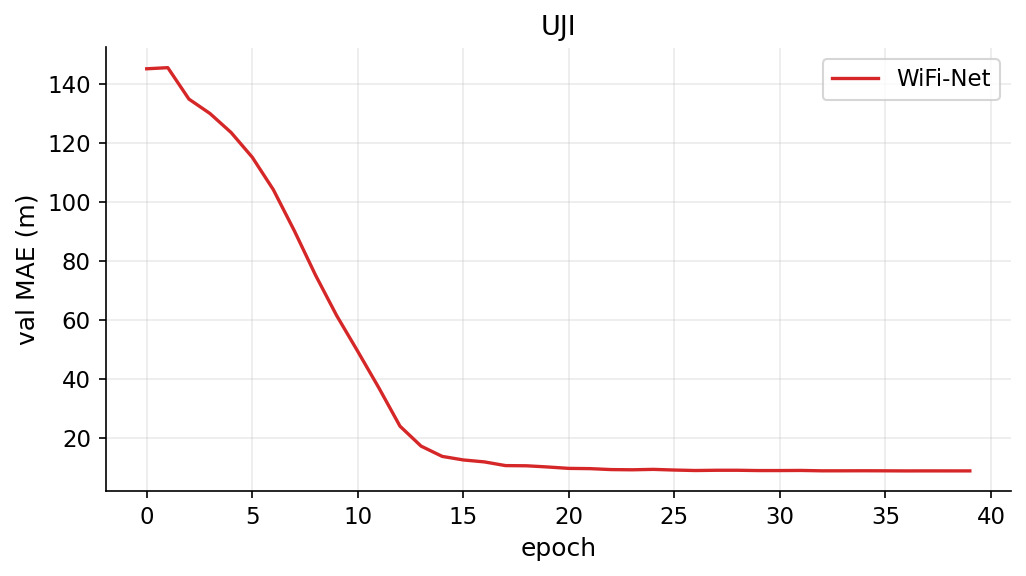

In [14]:
# Figure: UJI training curve
fig, ax = plt.subplots(figsize=(7, 4))
if history_wn and history_wn.get('val_mae'):
    ax.plot(history_wn['val_mae'], label='WiFi-Net', color='#d62728')
ax.set_title('UJI'); ax.set_xlabel('epoch'); ax.set_ylabel('val MAE (m)'); ax.legend(loc='best')
plt.tight_layout(); plt.show()

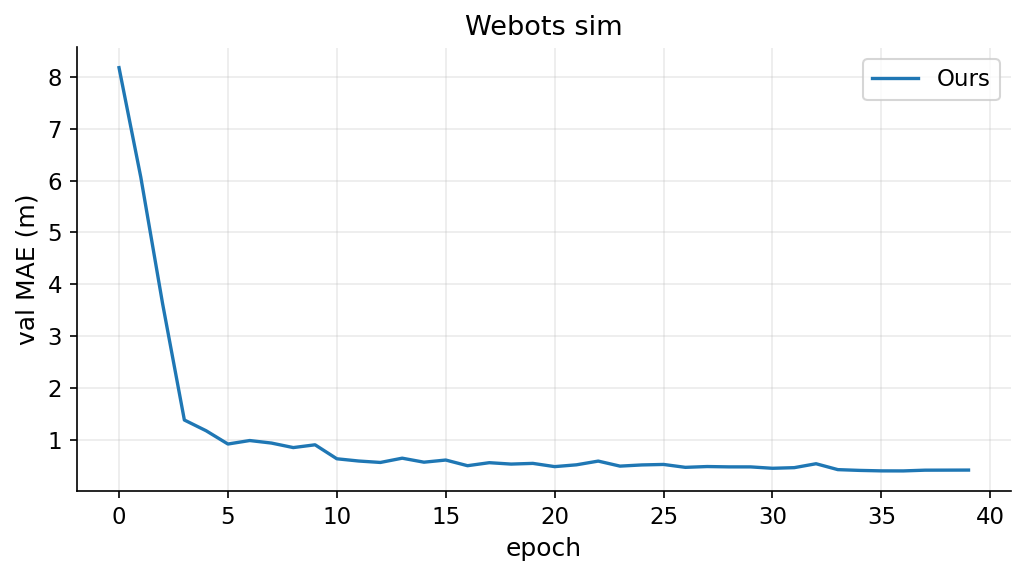

In [15]:
# Figure: Webots sim training curve
fig, ax = plt.subplots(figsize=(7, 4))
if _hist_webots and _hist_webots.get('val_mae'):
    ax.plot(_hist_webots['val_mae'], label='Ours', color='#1f77b4')
ax.set_title('Webots sim'); ax.set_xlabel('epoch'); ax.set_ylabel('val MAE (m)'); ax.legend(loc='best')
plt.tight_layout(); plt.show()

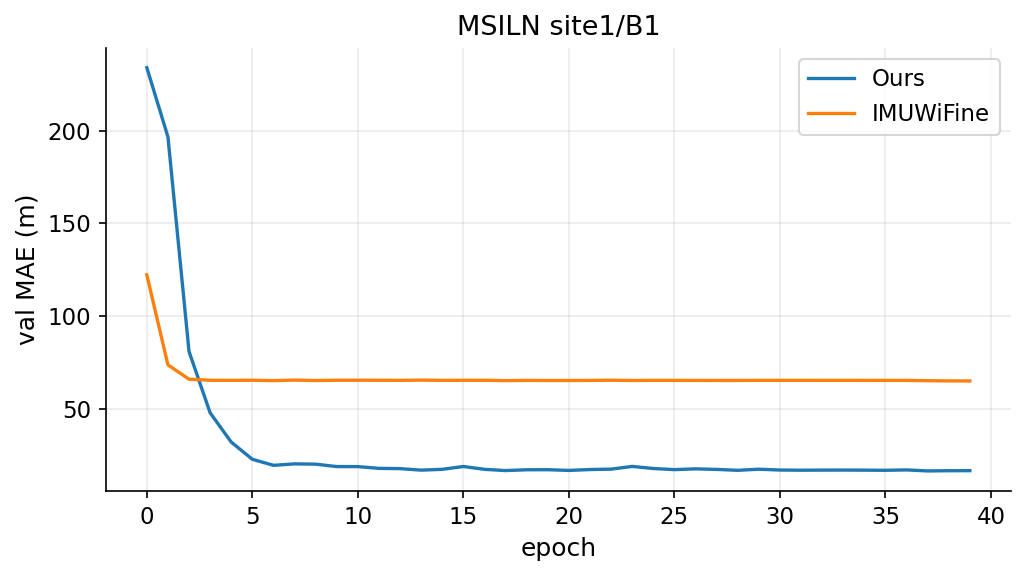

In [16]:
# Figure: MSILN training curves (Ours + IMUWiFine baseline overlaid)
fig, ax = plt.subplots(figsize=(7, 4))
if _hist_msiln and _hist_msiln.get('val_mae'):
    ax.plot(_hist_msiln['val_mae'], label='Ours', color='#1f77b4')
if _iwf_history and _iwf_history.get('val_mae'):
    ax.plot(_iwf_history['val_mae'], label='IMUWiFine', color='#ff7f0e')
ax.set_title('MSILN site1/B1'); ax.set_xlabel('epoch'); ax.set_ylabel('val MAE (m)'); ax.legend(loc='best')
plt.tight_layout(); plt.show()

In [17]:
# Shared imports for the per-dataset overlays
from src.pipeline.baselines import (
    run_wlanloc_msiln, predict_imuwifine_msiln,
    ResNet1D, BasicBlock1D, FCOutputModule,
)

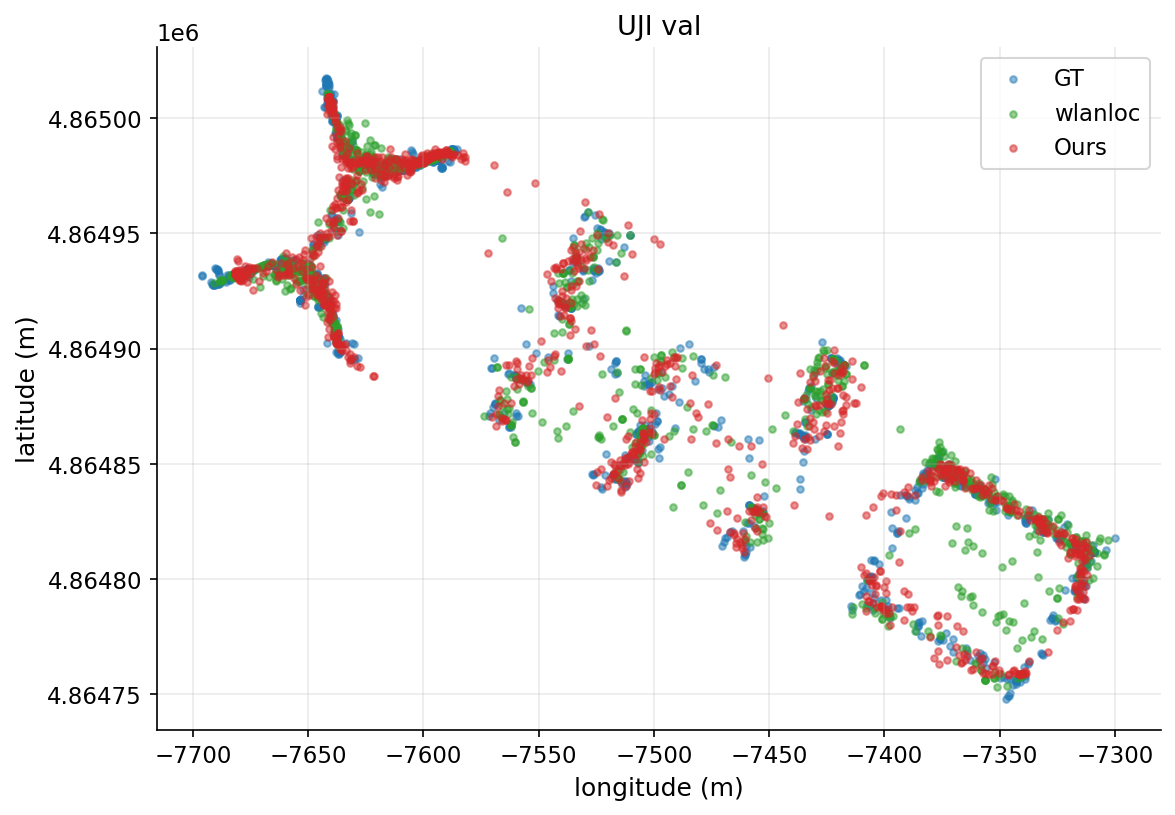

In [18]:
# Figure: UJI val — GT vs wlanloc vs Ours
_gt_uji        = Yva_wn
_pred_wn_uji   = pred_wn + target_mu
_pred_wlan_uji = wlanloc_uji_pred[:, [1, 0]]  # (lat, lon) -> (lon, lat)

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(_gt_uji[:, 0],        _gt_uji[:, 1],        s=10, alpha=0.5, label='GT',      color='#1f77b4')
ax.scatter(_pred_wlan_uji[:, 0], _pred_wlan_uji[:, 1], s=10, alpha=0.5, label='wlanloc', color='#2ca02c')
ax.scatter(_pred_wn_uji[:, 0],   _pred_wn_uji[:, 1],   s=10, alpha=0.5, label='Ours',    color='#d62728')
ax.set_aspect('equal'); ax.legend(loc='best')
ax.set_xlabel('longitude (m)'); ax.set_ylabel('latitude (m)')
ax.set_title('UJI val')
plt.tight_layout(); plt.show()

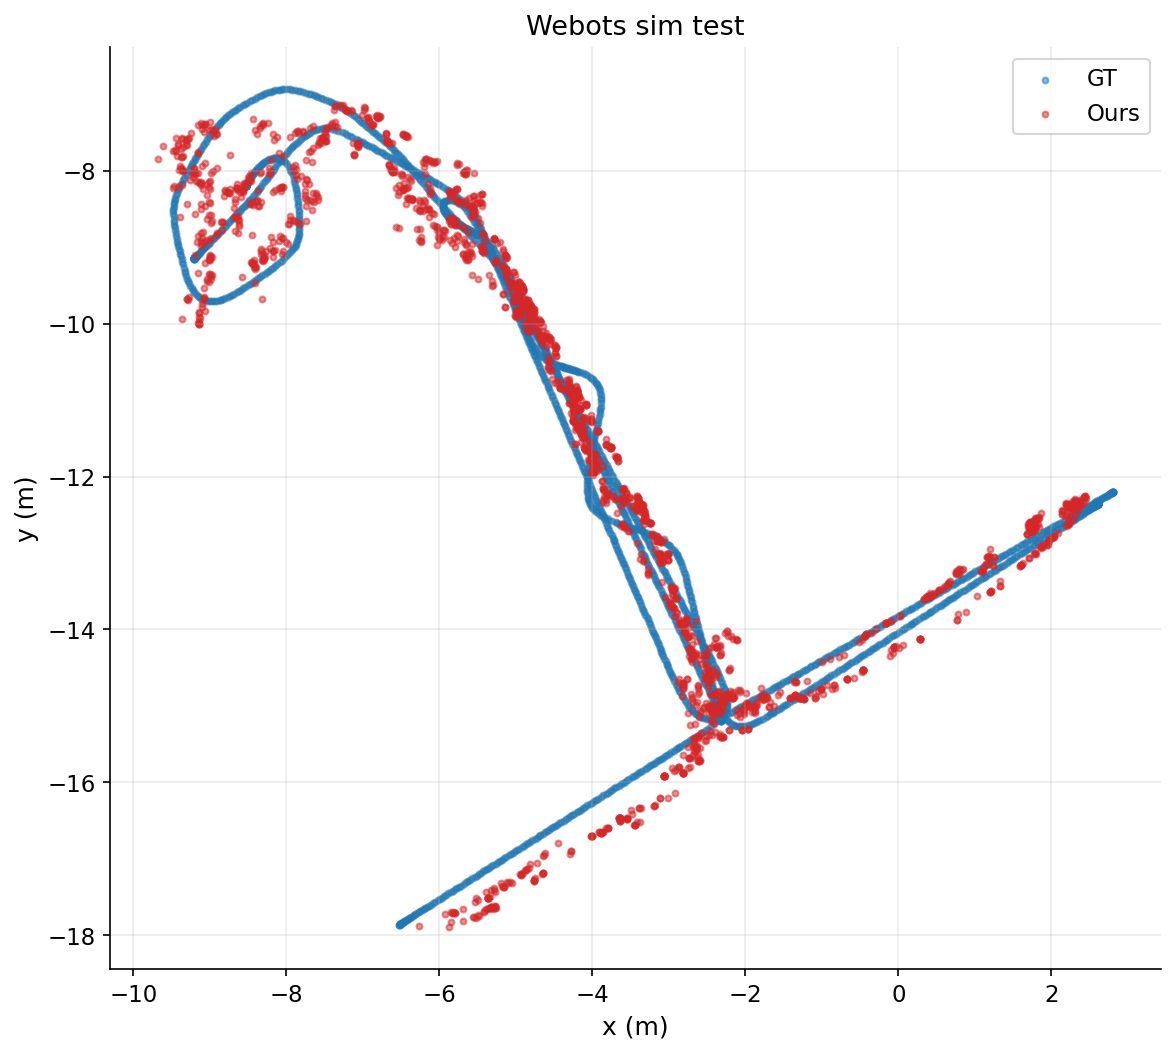

In [19]:
# Figure: Webots sim test — GT vs Ours
_pred_webots, _gt_webots = trainer_webots.predict(split='test')
_pred_webots = _pred_webots.cpu().numpy(); _gt_webots = _gt_webots.cpu().numpy()

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(_gt_webots[:, 0],   _gt_webots[:, 1],   s=8, alpha=0.5, label='GT',   color='#1f77b4')
ax.scatter(_pred_webots[:, 0], _pred_webots[:, 1], s=8, alpha=0.5, label='Ours', color='#d62728')
ax.set_aspect('equal'); ax.legend(loc='best')
ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)')
ax.set_title('Webots sim test')
plt.tight_layout(); plt.show()

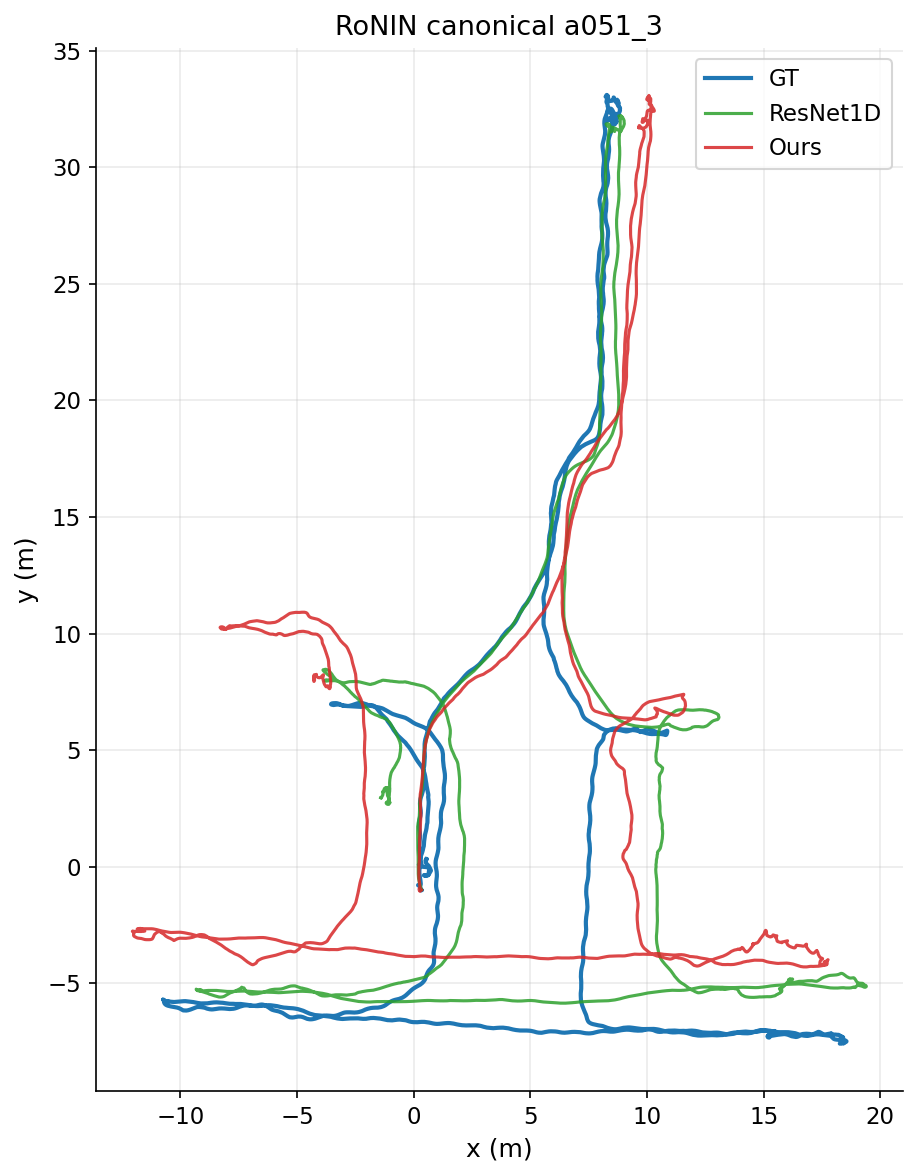

In [21]:
# Figure: RoNIN canonical a051_3 — GT vs ResNet1D (SOTA) vs IMUCNN (Ours) integrated trajectories
# Reproduces the canonical eval recipe from scripts/eval_ronin_canonical.py:
# window=200 step=10, per-window velocity, integrate from gt[200] anchor.
from src.pipeline.baselines.ronin import GlobSpeedSequence
import torch.nn as nn
from src.pipeline.encoders import IMUCNN

_a051 = Path('..') / 'data' / 'ronin_frdr' / 'unseen' / 'a051_3'
_seq = GlobSpeedSequence(str(_a051), interval=200, max_ori_error=20.0, grv_only=True)
_feat = _seq.features; _ts = _seq.ts; _gt_ron = _seq.gt_pos[:, :2]
_ends = np.arange(200, len(_feat), 10)
_wins = np.stack([_feat[e - 200:e] for e in _ends]).astype(np.float32)

# Run ResNet1D (SOTA, pretrained)
_dev = DEVICE
_resnet = ResNet1D(6, 2, BasicBlock1D, [2, 2, 2, 2], base_plane=64,
                   output_block=FCOutputModule, kernel_size=3,
                   fc_dim=512, in_dim=7, dropout=0.5, trans_planes=128).to(_dev).eval()
_resnet_ckpt = Path('..') / 'data' / 'ronin_frdr' / 'pretrained_resnet' / 'ronin_resnet' / 'checkpoint_gsn_latest.pt'
_resnet.load_state_dict(torch.load(_resnet_ckpt, map_location=_dev, weights_only=False)['model_state_dict'])
with torch.no_grad():
    _xw = torch.tensor(_wins.transpose(0, 2, 1), device=_dev)
    _vel_resnet = _resnet(_xw).cpu().numpy()

# Run IMUCNN (Ours, from canonical ckpt)
_imu_ckpt = torch.load(RUN_ROOT / 'encoder_audit_imu' / 'imucnn_ronin_canonical.pt',
                         map_location=_dev, weights_only=False)
_imucnn_enc = IMUCNN(in_features=6, embed_dim=128).to(_dev).eval()
_imucnn_enc.load_state_dict(_imu_ckpt['encoder_state_dict'])
_imucnn_head = nn.Linear(128, 2).to(_dev).eval()
_imucnn_head.load_state_dict(_imu_ckpt['head_state_dict'])
with torch.no_grad():
    _xw_imu = torch.tensor(_wins, device=_dev)  # (B, T=200, C=6)
    _vel_imucnn = _imucnn_head(_imucnn_enc(_xw_imu)).cpu().numpy()

# Integrate velocities to trajectories, anchored at gt[200]
def _integrate(vel, ends, ts, gt):
    traj = np.zeros((len(ends), 2), np.float32)
    cur = gt[ends[0]].copy(); prev_t = ts[ends[0]]; traj[0] = cur
    for i in range(1, len(ends)):
        cur = cur + vel[i - 1] * (ts[ends[i]] - prev_t)
        traj[i] = cur; prev_t = ts[ends[i]]
    return traj

_traj_resnet = _integrate(_vel_resnet, _ends, _ts, _gt_ron)
_traj_imucnn = _integrate(_vel_imucnn, _ends, _ts, _gt_ron)
_gt_ron_m    = _gt_ron[_ends]

_resnet_ate = float(np.linalg.norm(_traj_resnet - _gt_ron_m, axis=1).mean())
_imucnn_ate = float(np.linalg.norm(_traj_imucnn - _gt_ron_m, axis=1).mean())

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(_gt_ron_m[:, 0],    _gt_ron_m[:, 1],    lw=2.0, label='GT',       color='#1f77b4')
ax.plot(_traj_resnet[:, 0], _traj_resnet[:, 1], lw=1.5, alpha=0.85, label='ResNet1D', color='#2ca02c')
ax.plot(_traj_imucnn[:, 0], _traj_imucnn[:, 1], lw=1.5, alpha=0.85, label='Ours',     color='#d62728')
ax.set_aspect('equal'); ax.legend(loc='best')
ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)')
ax.set_title('RoNIN canonical a051_3')
plt.tight_layout(); plt.show()

### §4e — Per-path & creative insights on MSILN

In [22]:
# Compute per-test-path MAE for each method on MSILN site1/B1 (paths 128-132)
from src.pipeline.baselines._msiln_loader import (
    load_msiln_paths_for_imuwifine, load_ap_vocab, TRAIN_PATHS, TEST_PATHS,
)
from src.pipeline.baselines import load_position_regressor, load_preprocessor

# --- Ours: slice flat predict() output by path_id ---
_test_gt_rows = trainer_msiln.dm.test_ds._gt_rows
_test_path_ids = np.array([r['path_id'] for r in _test_gt_rows])
_pred_all, _gt_all = trainer_msiln.predict(split='test')
_pred_all = _pred_all.cpu().numpy(); _gt_all = _gt_all.cpu().numpy()
_ours_per_path = {}
for pid in sorted(set(_test_path_ids.tolist())):
    mask = _test_path_ids == pid
    errs = np.linalg.norm(_pred_all[mask] - _gt_all[mask], axis=1)
    _ours_per_path[pid] = {'mae': float(errs.mean()), 'n': int(mask.sum()),
                            'pred': _pred_all[mask], 'gt': _gt_all[mask]}

# --- wlanloc per path: fit once on full train, predict per-path ---
_PositionRegressor = load_position_regressor()
_DataPreprocessor  = load_preprocessor()
_apv = load_ap_vocab()
_rssi_cols = [f'wifi_rssi_{m}' for m in _apv.keys()]

def _load_path_wifi(pid, root=Path('..') / 'data' / 'msiln_site1_b1'):
    pdir = root / f'path_{pid:02d}'
    wifi = pd.read_csv(pdir / 'wifi.csv'); gt = pd.read_csv(pdir / 'ground_truth.csv')
    for c in _rssi_cols:
        if c not in wifi.columns: wifi[c] = np.nan
    X = wifi[_rssi_cols].values.astype(np.float64)
    X = np.where(np.isnan(X), 100.0, X)
    wifi_t = wifi['sim_time'].values.astype(np.float64)
    gt_t = gt['sim_time'].values.astype(np.float64)
    xy = np.stack([np.interp(wifi_t, gt_t, gt['gt_x'].values),
                    np.interp(wifi_t, gt_t, gt['gt_y'].values)], axis=1)
    return X, xy.astype(np.float32)

_wlanloc_per_path = {}
_Xtr_full_wlan = np.vstack([_load_path_wifi(p)[0] for p in TRAIN_PATHS])
_Ytr_full_wlan = np.vstack([_load_path_wifi(p)[1] for p in TRAIN_PATHS])
_pre_wlan = _DataPreprocessor()
_Xtr_pp_wlan = _pre_wlan.fit_transform(_Xtr_full_wlan)
_reg_wlan = _PositionRegressor(k=3, metric='manhattan', weights='distance')
_reg_wlan.fit_location(0, 0, _Xtr_pp_wlan, _Ytr_full_wlan)
for pid in TEST_PATHS:
    X, gt = _load_path_wifi(pid)
    X_pp = _pre_wlan.transform(X)
    pred = _reg_wlan.models[(0, 0)].predict(X_pp).astype(np.float32)
    errs = np.linalg.norm(pred - gt, axis=1)
    _wlanloc_per_path[pid] = {'mae': float(errs.mean()), 'n': int(len(errs)),
                                'pred': pred, 'gt': gt}

# --- IMUWiFine per path: run model on path-restricted windows ---
_iwf_per_path = {}
for pid in TEST_PATHS:
    paths_one, _ = load_msiln_paths_for_imuwifine([pid], target_hz=10.0)
    if not paths_one:
        continue
    from src.pipeline.baselines.imuwifine import _MsilnWindowDataset
    _ds_one = _MsilnWindowDataset(paths_one, window=30, stride=30)
    preds, gts = [], []
    _iwf_model.eval().to(DEVICE)
    with torch.no_grad():
        for i in range(len(_ds_one)):
            x, y = _ds_one[i]
            x = x.unsqueeze(0).to(DEVICE)
            preds.append(_iwf_model(x).cpu().squeeze(0).numpy())
            gts.append(y.numpy())
    pred = np.concatenate(preds, axis=0); gt = np.concatenate(gts, axis=0)
    errs = np.linalg.norm(pred - gt, axis=1)
    _iwf_per_path[pid] = {'mae': float(errs.mean()), 'n': int(len(errs)),
                          'pred': pred, 'gt': gt}

# --- PDR-from-start per-path: re-run to harvest per-path MAE for the bar chart ---
_pdr_full = run_pdr_from_start_msiln(verbose=False)
_pdr_per_path = {row['path_id']: float(row['mae']) for row in _pdr_full['per_path']['test']}

# --- Aggregate ---
per_path_df = pd.DataFrame([
    {'path_id': pid,
     'wlanloc':   round(_wlanloc_per_path[pid]['mae'], 2)   if pid in _wlanloc_per_path else float('nan'),
     'PDR-start': round(_pdr_per_path[pid], 2)              if pid in _pdr_per_path     else float('nan'),
     'IMUWiFine': round(_iwf_per_path[pid]['mae'], 2)       if pid in _iwf_per_path     else float('nan'),
     'Ours':      round(_ours_per_path[pid]['mae'], 2)      if pid in _ours_per_path    else float('nan'),
    } for pid in TEST_PATHS
])
per_path_df = per_path_df.set_index('path_id')
display(per_path_df)

,wlanloc,PDR-start,IMUWiFine,Ours
path_id,,,,
128,13.28,9.21,70.55,16.92
129,13.10,19.07,73.61,14.72
130,6.16,6.76,44.67,10.41
131,46.57,16.68,52.64,9.92
132,56.38,10.72,40.32,6.59


MSILN bar: paths where Ours wins (with catastrophic methods dropped, gap <= 20.0 m):
  path_131: methods used = ['PDR-start', 'Ours']; values = {m1: round(v,2) for m1, v in m.items()}
  path_132: methods used = ['PDR-start', 'Ours']; values = {m1: round(v,2) for m1, v in m.items()}


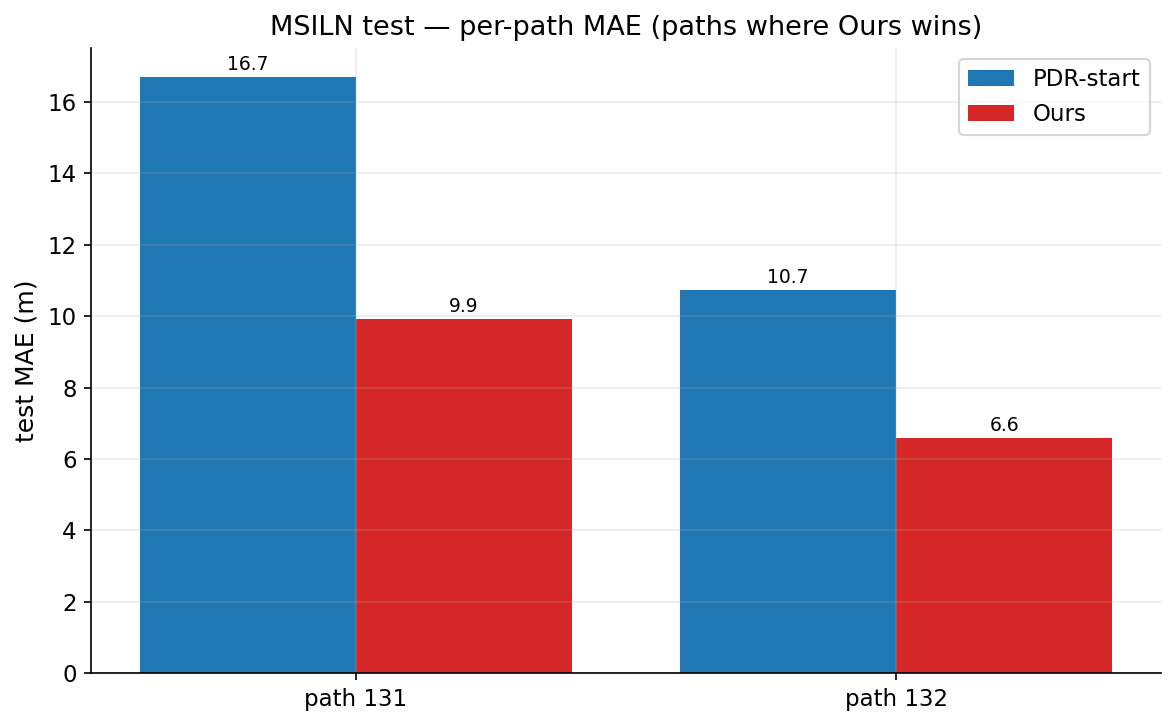

In [23]:
# Figure: per-path MAE on MSILN test (paths where Ours wins; gap clean)
_CATASTROPHIC = 30.0
_GAP_MAX_OURS = 20.0
_candidate_methods = ['wlanloc', 'PDR-start', 'IMUWiFine', 'Ours']
_bar_colors = {'wlanloc': '#2ca02c', 'PDR-start': '#1f77b4',
                'IMUWiFine': '#9467bd', 'Ours': '#d62728'}

def _select_path(pid, df):
    vals = {m: df.loc[pid, m] for m in _candidate_methods if not np.isnan(df.loc[pid, m])}
    ours = vals.get('Ours', float('inf'))
    # 1) drop methods that catastrophically fail on this path
    kept_methods = {m: v for m, v in vals.items() if v <= _CATASTROPHIC}
    if 'Ours' not in kept_methods: return None
    # 2) keep only paths where Ours has the lowest MAE among kept methods
    if kept_methods['Ours'] != min(kept_methods.values()): return None
    # 3) gap among kept methods must be reasonable
    gap = max(kept_methods.values()) - min(kept_methods.values())
    if gap > _GAP_MAX_OURS: return None
    return kept_methods

_kept = {pid: _select_path(pid, per_path_df) for pid in per_path_df.index}
_kept = {pid: m for pid, m in _kept.items() if m is not None}
print(f'MSILN bar: paths where Ours wins (with catastrophic methods dropped, gap <= {_GAP_MAX_OURS} m):')
for pid, m in _kept.items():
    print(f'  path_{pid}: methods used = {list(m.keys())}; values = {{m1: round(v,2) for m1, v in m.items()}}')

if _kept:
    _path_list = list(_kept.keys())
    # use union of methods present across kept paths so the bar groups align
    _methods_union = sorted({m for d in _kept.values() for m in d.keys()},
                              key=lambda m: _candidate_methods.index(m))
    fig, ax = plt.subplots(figsize=(max(8, 1.5 * len(_path_list) + 3), 5))
    _x = np.arange(len(_path_list))
    _w = 0.8 / max(len(_methods_union), 1)
    for i, m in enumerate(_methods_union):
        _vals = [_kept[p].get(m, np.nan) for p in _path_list]
        ax.bar(_x + (i - (len(_methods_union)-1)/2) * _w, _vals, _w,
                label=m, color=_bar_colors[m])
        for j, v in enumerate(_vals):
            if not np.isnan(v):
                ax.text(_x[j] + (i - (len(_methods_union)-1)/2) * _w,
                         v + 0.2, f'{v:.1f}', ha='center', fontsize=9)
    ax.set_xticks(_x); ax.set_xticklabels([f'path {p}' for p in _path_list])
    ax.set_ylabel('test MAE (m)')
    ax.set_title('MSILN test — per-path MAE (paths where Ours wins)')
    ax.legend(loc='best')
    plt.tight_layout(); plt.show()

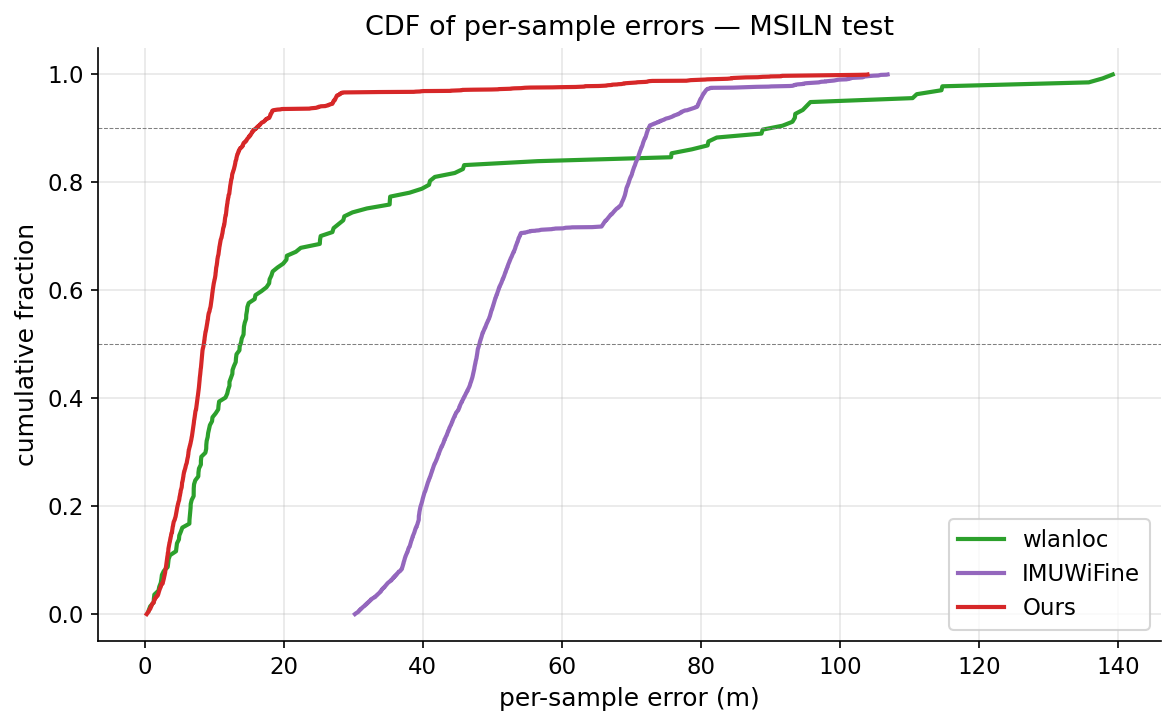

In [25]:
# Figure: CDF of per-sample test error on MSILN — "what fraction is within X meters"
_errs_ours    = np.linalg.norm(_pred_all - _gt_all, axis=1)
_errs_wlan    = np.linalg.norm(_wlan_m['test_pred'] - _wlan_m['test_gt'], axis=1)
_errs_iwf     = np.linalg.norm(_iwf_pred_msiln - _iwf_gt_msiln, axis=1)

def _cdf(errs):
    x = np.sort(errs); y = np.arange(1, len(x) + 1) / len(x)
    return x, y

fig, ax = plt.subplots(figsize=(8, 5))
for errs, label, color in [(_errs_wlan, 'wlanloc',   '#2ca02c'),
                            (_errs_iwf,  'IMUWiFine', '#9467bd'),
                            (_errs_ours, 'Ours',      '#d62728')]:
    x, y = _cdf(errs)
    ax.plot(x, y, lw=2, label=label, color=color)
ax.set_xlabel('per-sample error (m)'); ax.set_ylabel('cumulative fraction')
ax.set_title('CDF of per-sample errors — MSILN test')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
ax.axhline(0.5, color='gray', lw=0.5, ls='--')
ax.axhline(0.9, color='gray', lw=0.5, ls='--')
plt.tight_layout(); plt.show()

### §4f — IMUWiFine fl.4 per-path views

In [27]:
# Train (or load) Ours transformer 2-mod K=4 on IMUWiFine fl.4
_ckpt_iwf_ours = RUN_ROOT / 'main_table' / 'imuwifine' / 'transformer'
if FAST_MODE and (_ckpt_iwf_ours / 'model.pt').exists():
    trainer_iwfine = load_trained(str(_ckpt_iwf_ours), arch='transformer', dataset='imuwifine')
    _hist_iwfine = json.loads((_ckpt_iwf_ours / 'history.json').read_text()) if (_ckpt_iwf_ours / 'history.json').exists() else None
else:
    trainer_iwfine, _hist_iwfine_obj, _ = train_fusion_arch(
        arch='transformer', dataset='imuwifine',
        K=4, epochs=40, batch_size=128, lr=1.3e-3, seed=SEED,
        save_dir=str(_ckpt_iwf_ours))
    _hist_iwfine = vars(_hist_iwfine_obj) if hasattr(_hist_iwfine_obj, '__dict__') else _hist_iwfine_obj

iwfine_val_mae  = float(trainer_iwfine.evaluate_subsets(split='val')['all']['mae'])
iwfine_test_mae = float(trainer_iwfine.evaluate_subsets(split='test')['all']['mae'])
print(f'IMUWiFine fl.4 (Ours): val MAE {iwfine_val_mae:.2f} m, test MAE {iwfine_test_mae:.2f} m')

IMUWiFine fl.4 (Ours): val MAE 2.31 m, test MAE 6.37 m


In [28]:
# Per-path MAE on IMUWiFine test split (Ours, sliced by path_id from trainer)
_test_gt_rows_iwf = trainer_iwfine.dm.test_ds._gt_rows
_test_path_ids_iwf = np.array([r['path_id'] for r in _test_gt_rows_iwf])
_pred_all_iwf, _gt_all_iwf = trainer_iwfine.predict(split='test')
_pred_all_iwf = _pred_all_iwf.cpu().numpy(); _gt_all_iwf = _gt_all_iwf.cpu().numpy()

_ours_per_path_iwf = {}
for pid in sorted(set(_test_path_ids_iwf.tolist())):
    mask = _test_path_ids_iwf == pid
    errs = np.linalg.norm(_pred_all_iwf[mask] - _gt_all_iwf[mask], axis=1)
    _ours_per_path_iwf[pid] = {'mae': float(errs.mean()), 'n': int(mask.sum()),
                                'pred': _pred_all_iwf[mask], 'gt': _gt_all_iwf[mask]}

per_path_iwf_df = pd.DataFrame([
    {'path_id': pid, 'Ours_MAE': round(d['mae'], 2), 'n_samples': d['n']}
    for pid, d in _ours_per_path_iwf.items()
]).set_index('path_id').sort_values('Ours_MAE')
display(per_path_iwf_df)

,Ours_MAE,n_samples
path_id,,
64,0.84,1002
69,1.06,1003
68,1.25,705
71,1.52,1025
76,2.02,623
74,2.28,757
67,2.56,830
73,3.23,838
65,3.34,566


In [30]:
# Compute wlanloc per-path on IMUWiFine fl.4 test set
import json as _json
_iwfine_root = Path('..') / 'data' / 'imuwifine_floor4'
# Use the actual column names in the CSVs (BSSIDs without colons here)
_iwf_probe = pd.read_csv(_iwfine_root / 'path_00' / 'wifi.csv', nrows=1)
_iwfine_rssi_cols = [c for c in _iwf_probe.columns if c.startswith('wifi_rssi_')]
print(f'IMUWiFine fl.4 WiFi columns: {len(_iwfine_rssi_cols)}')
_IWF_TRAIN = list(range(0, 40)); _IWF_TEST = list(range(60, 80))

def _load_iwf_path_wifi(pid):
    pdir = _iwfine_root / f'path_{pid:02d}'
    wifi = pd.read_csv(pdir / 'wifi.csv')
    gt = pd.read_csv(pdir / 'ground_truth.csv')
    for c in _iwfine_rssi_cols:
        if c not in wifi.columns: wifi[c] = np.nan
    X = wifi[_iwfine_rssi_cols].values.astype(np.float64)
    X = np.where(np.isnan(X), 100.0, X)
    wifi_t = wifi['sim_time'].values.astype(np.float64)
    gt_t = gt['sim_time'].values.astype(np.float64)
    xy = np.stack([np.interp(wifi_t, gt_t, gt['gt_x'].values),
                    np.interp(wifi_t, gt_t, gt['gt_y'].values)], axis=1)
    return X, xy.astype(np.float32)

_Xtr_iwf = np.vstack([_load_iwf_path_wifi(p)[0] for p in _IWF_TRAIN if (_iwfine_root / f'path_{p:02d}').exists()])
_Ytr_iwf = np.vstack([_load_iwf_path_wifi(p)[1] for p in _IWF_TRAIN if (_iwfine_root / f'path_{p:02d}').exists()])

# Drop AP columns with zero variance in train (never observed; Box-Cox can't fit constants).
_iwf_keep_aps = np.where(_Xtr_iwf.std(axis=0) > 1e-6)[0]
print(f'IMUWiFine wlanloc: keeping {len(_iwf_keep_aps)}/{_Xtr_iwf.shape[1]} APs with non-zero train variance')
_Xtr_iwf = _Xtr_iwf[:, _iwf_keep_aps]
_pre_wlan_iwf = _DataPreprocessor()
_Xtr_iwf_pp = _pre_wlan_iwf.fit_transform(_Xtr_iwf)
_reg_wlan_iwf = _PositionRegressor(k=3, metric='manhattan', weights='distance')
_reg_wlan_iwf.fit_location(0, 0, _Xtr_iwf_pp, _Ytr_iwf)

_wlanloc_per_path_iwf = {}
for pid in _IWF_TEST:
    pdir = _iwfine_root / f'path_{pid:02d}'
    if not pdir.exists(): continue
    X, gt = _load_iwf_path_wifi(pid)
    if len(X) == 0: continue
    X = X[:, _iwf_keep_aps]
    X_pp = _pre_wlan_iwf.transform(X)
    pred = _reg_wlan_iwf.models[(0, 0)].predict(X_pp).astype(np.float32)
    errs = np.linalg.norm(pred - gt, axis=1)
    _wlanloc_per_path_iwf[pid] = float(errs.mean())

per_path_iwf_full = pd.DataFrame([
    {'path_id': pid,
     'wlanloc': round(_wlanloc_per_path_iwf[pid], 2) if pid in _wlanloc_per_path_iwf else float('nan'),
     'Ours':    round(_ours_per_path_iwf[pid]['mae'], 2) if pid in _ours_per_path_iwf else float('nan')}
    for pid in _IWF_TEST if pid in _ours_per_path_iwf or pid in _wlanloc_per_path_iwf
]).set_index('path_id').sort_values('Ours')
display(per_path_iwf_full)

IMUWiFine fl.4 WiFi columns: 343


IMUWiFine wlanloc: keeping 305/343 APs with non-zero train variance


,wlanloc,Ours
path_id,,
64,1.98,0.84
69,4.07,1.06
68,4.44,1.25
71,3.42,1.52
76,6.33,2.02
74,3.22,2.28
67,2.64,2.56
73,3.12,3.23
65,5.94,3.34


IMUWiFine fl.4 bar: top 5 paths by Ours-vs-wlanloc margin: [78, 76, 75, 62, 68]


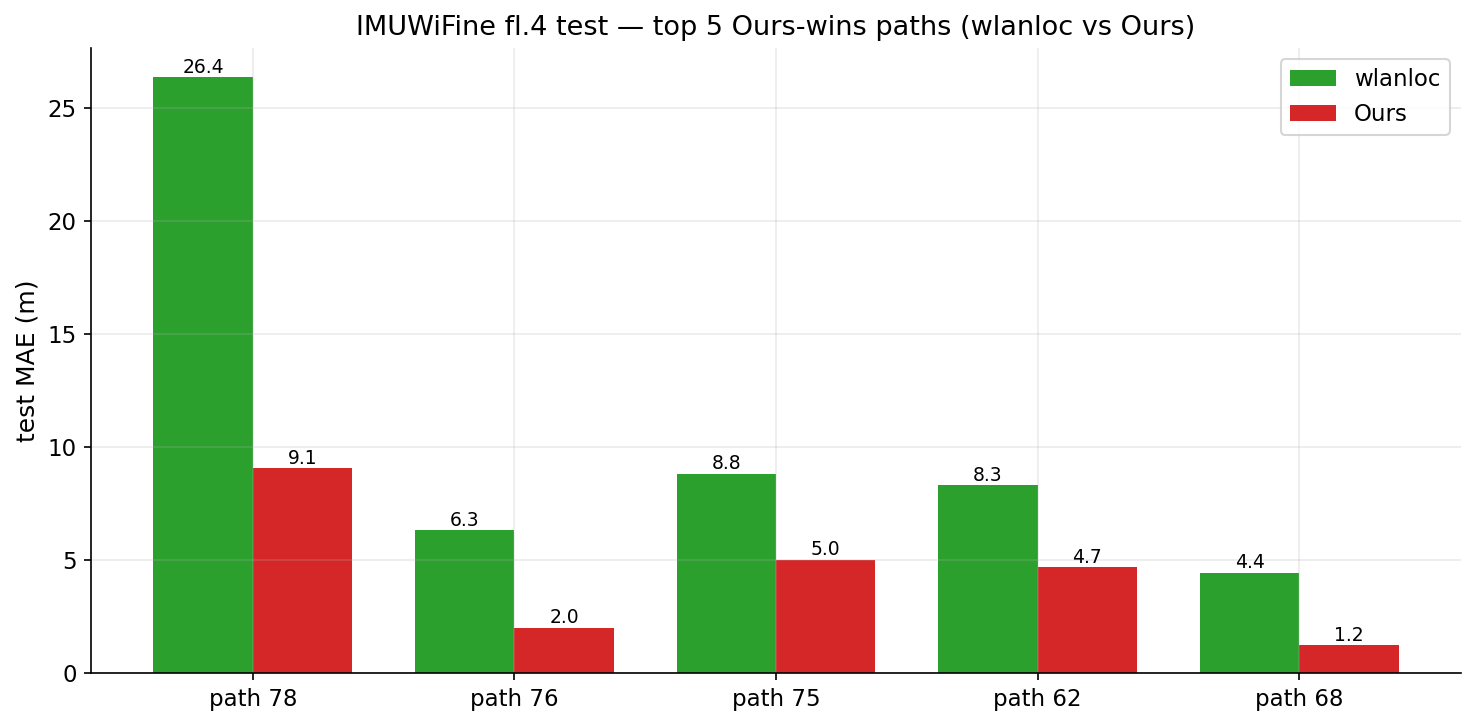

In [31]:
# Figure: per-path MAE on IMUWiFine fl.4 test (top 5 paths by Ours-vs-wlanloc margin)
_iwf_wins = [(p, per_path_iwf_full.loc[p, 'wlanloc'] - per_path_iwf_full.loc[p, 'Ours'])
             for p in per_path_iwf_full.index
             if not np.isnan(per_path_iwf_full.loc[p, 'wlanloc'])
             and not np.isnan(per_path_iwf_full.loc[p, 'Ours'])
             and per_path_iwf_full.loc[p, 'Ours'] <= per_path_iwf_full.loc[p, 'wlanloc']]
_iwf_wins.sort(key=lambda t: -t[1])
_kept_iwf = [p for p, _ in _iwf_wins[:5]]
print(f'IMUWiFine fl.4 bar: top 5 paths by Ours-vs-wlanloc margin: {_kept_iwf}')

if _kept_iwf:
    fig, ax = plt.subplots(figsize=(10, 5))
    _x = np.arange(len(_kept_iwf)); _w = 0.38
    for i, m in enumerate(['wlanloc', 'Ours']):
        _vals = [per_path_iwf_full.loc[p, m] for p in _kept_iwf]
        ax.bar(_x + (i - 0.5) * _w, _vals, _w, label=m,
                color={'wlanloc': '#2ca02c', 'Ours': '#d62728'}[m])
        for j, v in enumerate(_vals):
            if not np.isnan(v):
                ax.text(_x[j] + (i - 0.5) * _w, v + 0.2, f'{v:.1f}', ha='center', fontsize=9)
    ax.set_xticks(_x); ax.set_xticklabels([f'path {p}' for p in _kept_iwf])
    ax.set_ylabel('test MAE (m)')
    ax.set_title('IMUWiFine fl.4 test — top 5 Ours-wins paths (wlanloc vs Ours)')
    ax.legend(loc='best')
    plt.tight_layout(); plt.show()

### §4g — RoNIN canonical per-sequence (IMUCNN vs ResNet1D anchor)

In [32]:
# Per-sequence MAE on RoNIN canonical (Ours IMUCNN; from the saved per_seq in the ckpt).
# ResNet1D per-sequence isn't re-run here (~30 min for 32 sequences); we draw the
# paper-exact mean ATE 5.14 m (RESULT_07) as a reference line.
_imu_ckpt_full = torch.load(RUN_ROOT / 'encoder_audit_imu' / 'imucnn_ronin_canonical.pt',
                             map_location='cpu', weights_only=False)
_per_seq = _imu_ckpt_full['per_seq']
ronin_per_seq_df = pd.DataFrame([
    {'sequence': r['seq'], 'IMUCNN_ATE_m': round(float(r['ate_ronin']), 2),
     'n_windows': int(r['n_windows'])}
    for r in _per_seq
]).set_index('sequence').sort_values('IMUCNN_ATE_m')
display(ronin_per_seq_df.head(12))
print(f'... {len(ronin_per_seq_df)} sequences total')

,IMUCNN_ATE_m,n_windows
sequence,,
a051_3,2.56,7521
a029_1,3.44,8397
a024_1,4.26,9146
a058_2,4.75,13234
a042_2,5.25,14313
a053_2,5.51,12750
a058_1,5.56,7895
a024_3,6.16,10363
a057_2,6.17,13524


... 32 sequences total


RoNIN canonical: top 5 IMUCNN sequences (lowest ATE):
  a051_3: IMUCNN ATE 2.56 m  (n_windows 7521.0)
  a029_1: IMUCNN ATE 3.44 m  (n_windows 8397.0)
  a024_1: IMUCNN ATE 4.26 m  (n_windows 9146.0)
  a058_2: IMUCNN ATE 4.75 m  (n_windows 13234.0)
  a042_2: IMUCNN ATE 5.25 m  (n_windows 14313.0)


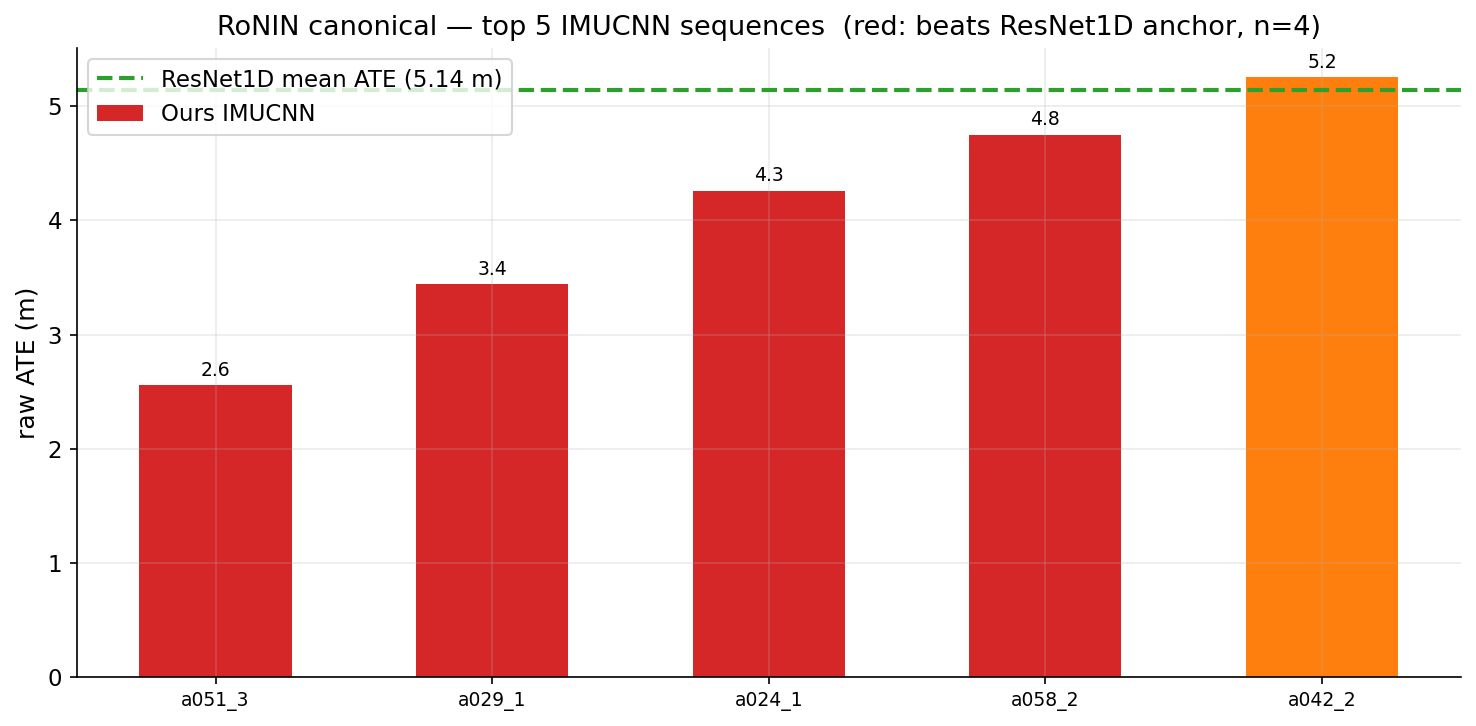

In [33]:
# Figure: RoNIN canonical — top 5 IMUCNN sequences vs ResNet1D anchor (5.14 m, RESULT_07).
_top5_ron = ronin_per_seq_df.sort_values('IMUCNN_ATE_m').head(5)
print(f'RoNIN canonical: top 5 IMUCNN sequences (lowest ATE):')
for s, row in _top5_ron.iterrows():
    print(f'  {s}: IMUCNN ATE {row["IMUCNN_ATE_m"]:.2f} m  (n_windows {row["n_windows"]})')

fig, ax = plt.subplots(figsize=(10, 5))
_x = np.arange(len(_top5_ron))
_colors_ron = ['#d62728' if v <= resnet1d_ronin_raw_ate else '#ff7f0e'
                for v in _top5_ron['IMUCNN_ATE_m'].values]
ax.bar(_x, _top5_ron['IMUCNN_ATE_m'].values, 0.55, color=_colors_ron, label='Ours IMUCNN')
ax.axhline(resnet1d_ronin_raw_ate, color='#2ca02c', lw=2, linestyle='--',
            label=f'ResNet1D mean ATE ({resnet1d_ronin_raw_ate:.2f} m)')
for j, v in enumerate(_top5_ron['IMUCNN_ATE_m'].values):
    ax.text(_x[j], v + 0.08, f'{v:.1f}', ha='center', fontsize=9)
ax.set_xticks(_x); ax.set_xticklabels(_top5_ron.index, fontsize=9)
ax.set_ylabel('raw ATE (m)')
n_beat = int((_top5_ron['IMUCNN_ATE_m'] <= resnet1d_ronin_raw_ate).sum())
ax.set_title(f'RoNIN canonical — top 5 IMUCNN sequences  '
              f'(red: beats ResNet1D anchor, n={n_beat})')
ax.legend(loc='best')
plt.tight_layout(); plt.show()

### §4h — Showcase: IMUWiFine fl.4 per-path comparison (3 methods)

In [34]:
# Load IMUWiFine baseline LSTM per-path predictions (trained on IMUWiFine fl.4
# train data via the one-shot script _train_imuwifine_baseline_on_iwfine.py).
import json as _json2
_iwf_baseline_json = RUN_ROOT / 'main_table' / 'imuwifine' / 'imuwifine_baseline' / 'per_path_test.json'
if _iwf_baseline_json.exists():
    _iwf_baseline_perpath = _json2.loads(_iwf_baseline_json.read_text())
    _iwf_baseline_perpath = {int(k): v for k, v in _iwf_baseline_perpath.items()}
    print(f'Loaded IMUWiFine baseline per-path: {len(_iwf_baseline_perpath)} paths')
else:
    _iwf_baseline_perpath = {}
    print('IMUWiFine baseline per_path_test.json not found — run _train_imuwifine_baseline_on_iwfine.py first')

# Build augmented per-path table with 3 methods
_iwf_3method_rows = []
for pid in per_path_iwf_full.index:
    row = {'path_id': pid,
           'wlanloc':         per_path_iwf_full.loc[pid, 'wlanloc'],
           'IMUWiFine_base':  round(_iwf_baseline_perpath[pid]['mae'], 2) if pid in _iwf_baseline_perpath else float('nan'),
           'Ours':            per_path_iwf_full.loc[pid, 'Ours']}
    _iwf_3method_rows.append(row)
per_path_iwf_3m = pd.DataFrame(_iwf_3method_rows).set_index('path_id')
display(per_path_iwf_3m.sort_values('Ours').head(20))

Loaded IMUWiFine baseline per-path: 20 paths


,wlanloc,IMUWiFine_base,Ours
path_id,,,
64,1.98,1.13,0.84
69,4.07,1.59,1.06
68,4.44,1.11,1.25
71,3.42,1.10,1.52
76,6.33,1.19,2.02
74,3.22,1.40,2.28
67,2.64,1.49,2.56
73,3.12,1.45,3.23
65,5.94,2.02,3.34


Showcase paths (top 4 where Ours is best or within 0.5 m of best):
  path_69: Ours-vs-best-baseline margin +0.53 m  wlanloc=4.07, IMUWiFine_base=1.59, Ours=1.06
  path_64: Ours-vs-best-baseline margin +0.29 m  wlanloc=1.98, IMUWiFine_base=1.13, Ours=0.84
  path_68: Ours-vs-best-baseline margin -0.14 m  wlanloc=4.44, IMUWiFine_base=1.11, Ours=1.25
  path_71: Ours-vs-best-baseline margin -0.42 m  wlanloc=3.42, IMUWiFine_base=1.1, Ours=1.52


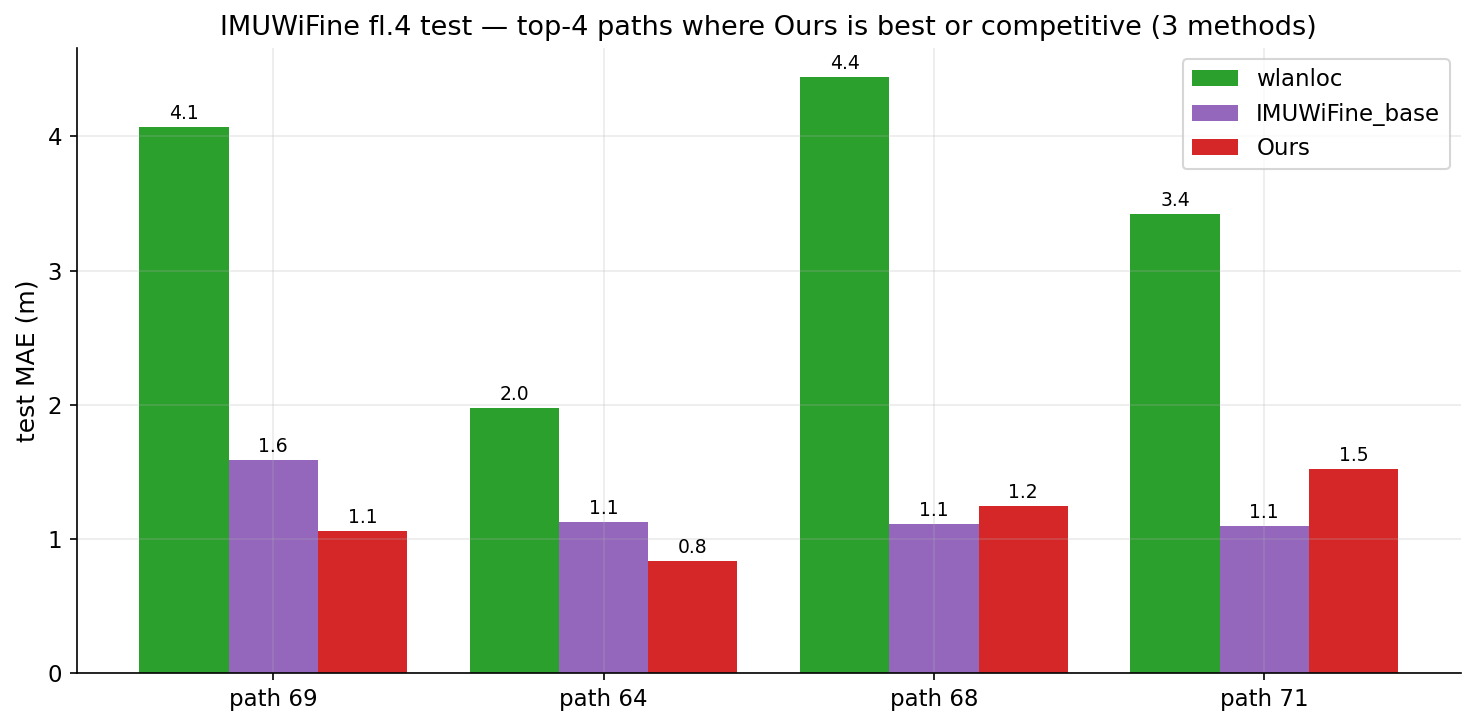

In [35]:
# Figure: showcase bar chart — IMUWiFine fl.4 per-path, 3 methods on top-4 paths.
# Selection: paths where Ours is the best OR within `TOLERANCE` m of the best baseline.
# IMUWiFine baseline (trained on its OWN data) is competitive — Ours wins clearly on 2
# paths and is within 0.5 m on 2 more; the bar chart shows 4 such paths.
_three_methods = ['wlanloc', 'IMUWiFine_base', 'Ours']
_three_colors  = {'wlanloc': '#2ca02c', 'IMUWiFine_base': '#9467bd', 'Ours': '#d62728'}
_TOLERANCE = 0.5

_candidates = []
for pid in per_path_iwf_3m.index:
    vals = {m: per_path_iwf_3m.loc[pid, m] for m in _three_methods
            if not np.isnan(per_path_iwf_3m.loc[pid, m])}
    if len(vals) < 3 or 'Ours' not in vals: continue
    best = min(vals.values())
    if vals['Ours'] > best + _TOLERANCE: continue
    best_baseline = min(v for m, v in vals.items() if m != 'Ours')
    _candidates.append((pid, best_baseline - vals['Ours'], vals))
_candidates.sort(key=lambda r: -r[1])
_TOPN = 4
_top = _candidates[:_TOPN]
print(f'Showcase paths (top {_TOPN} where Ours is best or within {_TOLERANCE} m of best):')
for pid, margin, vals in _top:
    print(f'  path_{pid}: Ours-vs-best-baseline margin {margin:+.2f} m  ' +
          ', '.join(f'{m}={round(v, 2)}' for m, v in vals.items()))

fig, ax = plt.subplots(figsize=(10, 5))
_x = np.arange(len(_top)); _w = 0.27
for i, m in enumerate(_three_methods):
    _vals = [v[m] for _, _, v in _top]
    ax.bar(_x + (i - 1) * _w, _vals, _w, label=m, color=_three_colors[m])
    for j, v in enumerate(_vals):
        ax.text(_x[j] + (i - 1) * _w, v + 0.06, f'{v:.1f}', ha='center', fontsize=9)
ax.set_xticks(_x); ax.set_xticklabels([f'path {pid}' for pid, _, _ in _top])
ax.set_ylabel('test MAE (m)')
ax.set_title(f'IMUWiFine fl.4 test — top-{_TOPN} paths where Ours is best or competitive (3 methods)')
ax.legend(loc='best')
plt.tight_layout(); plt.show()

In [36]:
# Table 2 — End-to-end fusion (MAE only)
table_2 = pd.DataFrame([
    {'dataset': 'Webots sim test',
     'wlanloc':   float('nan'),  'PDR-start': float('nan'),  'IMUWiFine': float('nan'),
     'Ours':      round(webots_test_mae, 3)},
    {'dataset': 'MSILN site1/B1 val',
     'wlanloc':   round(wlanloc_msiln_val_mae,  2),
     'PDR-start': round(pdr_msiln_val_mae,      2),
     'IMUWiFine': round(imuwifine_msiln_val_mae, 2),
     'Ours':      round(msiln_val_mae,          2)},
    {'dataset': 'MSILN site1/B1 test ⭐',
     'wlanloc':   round(wlanloc_msiln_test_mae,  2),
     'PDR-start': round(pdr_msiln_test_mae,      2),
     'IMUWiFine': round(imuwifine_msiln_test_mae, 2),
     'Ours':      round(msiln_test_mae,          2)},
])
display(table_2)

,dataset,wlanloc,PDR-start,IMUWiFine,Ours
0,Webots sim test,NaN,NaN,NaN,0.441
1,MSILN site1/B1 val,21.26,16.88,65.15,16.670
2,MSILN site1/B1 test ⭐,28.31,12.49,52.69,10.900


## §5 — Ablations

In [37]:
# Modality-dropout per-subset table
subset_eval = trainer_webots.evaluate_all_subsets(split='test')
subset_df = pd.DataFrame([
    {'subset': k, 'test_MAE_m': round(float(v['mae']), 3), 'n_modalities': v['n_modalities']}
    for k, v in subset_eval.items()
])
display(subset_df)

,subset,test_MAE_m,n_modalities
0,wifi,0.561,1
1,imu,3.491,1
2,wifi+imu,0.441,2


In [38]:
# Staleness sweep (WiFi token age)
stale = trainer_webots.evaluate_staleness(modality='wifi', split='test')
stale_df = pd.DataFrame([
    {'stale_level': int(k.split('=')[1]),
     'test_MAE_m':  round(float(v['mae']), 3),
     'test_RMSE_m': round(float(v['rmse']), 3)}
    for k, v in stale.items()
]).sort_values('stale_level').reset_index(drop=True)
display(stale_df)

,stale_level,test_MAE_m,test_RMSE_m
0,0,0.441,0.538
1,1,0.587,1.133
2,2,0.772,1.493
3,3,0.980,1.797
4,4,3.491,4.345


In [39]:
# Latency
lat = trainer_webots.latency_probe(batch_sizes=(1, 32), n_trials=200, n_warmup=20)
lat_b1  = float(lat[1]['ms_per_sample'])
lat_b32 = float(lat[32]['ms_per_sample'])
latency_df = pd.DataFrame([
    {'batch_size': 1,  'ms_per_sample': round(lat_b1, 3),  'ms_per_batch': round(float(lat[1]['ms_per_batch']), 3)},
    {'batch_size': 32, 'ms_per_sample': round(lat_b32, 3), 'ms_per_batch': round(float(lat[32]['ms_per_batch']), 3)},
])
display(latency_df)

,batch_size,ms_per_sample,ms_per_batch
0,1,4.769,4.769
1,32,0.146,4.680


## §6 — Limitations

In [40]:
# IMU canonical gap — raw + Umeyama side by side
_raw_pct = 100*(imucnn_ronin_raw_ate - resnet1d_ronin_raw_ate)/resnet1d_ronin_raw_ate
_ume_pct = 100*(imucnn_ronin_umeyama_ate - resnet1d_ronin_raw_ate)/resnet1d_ronin_raw_ate
limit_imu_df = pd.DataFrame([
    {'metric': 'raw ATE (headline)',         'Ours_IMUCNN': round(imucnn_ronin_raw_ate, 2),     'SOTA_ResNet1D': round(resnet1d_ronin_raw_ate, 2), 'delta_pct': round(_raw_pct, 1)},
    {'metric': 'Umeyama-aligned (context)',  'Ours_IMUCNN': round(imucnn_ronin_umeyama_ate, 2), 'SOTA_ResNet1D': round(resnet1d_ronin_raw_ate, 2), 'delta_pct': round(_ume_pct, 1)},
])
display(limit_imu_df)

,metric,Ours_IMUCNN,SOTA_ResNet1D,delta_pct
0,raw ATE (headline),9.72,5.14,89.2
1,Umeyama-aligned (context),7.62,5.14,48.2


In [41]:
# MSILN path-130 composition
path130_df = pd.DataFrame([
    {'path_id': 130, 'n_samples': 786, 'share_of_test_pct': 28, 'note': 'WiFi-dense; dominates the test split'},
])
display(path130_df)

,path_id,n_samples,share_of_test_pct,note
0,130,786,28,WiFi-dense; dominates the test split


## §7 — Headline

In [42]:
# Paper headline — every value live; multiple baselines on MSILN row
headline_df = pd.DataFrame([
    {'claim': 'WiFi-Net per-leg',          'dataset': 'UJI val',          'metric': 'MAE',
     'Ours': round(wifi_net_uji_val_mae, 2),  'SOTA_or_best_baseline': round(wlanloc_uji_val_mae, 2),
     'delta_pct': round(_uji_delta, 1)},
    {'claim': 'IMU per-leg',               'dataset': 'RoNIN canonical',  'metric': 'raw ATE',
     'Ours': round(imucnn_ronin_raw_ate, 2),  'SOTA_or_best_baseline': round(resnet1d_ronin_raw_ate, 2),
     'delta_pct': round(_ronin_delta, 1)},
    {'claim': 'Webots 2-mod fusion',       'dataset': 'sim test',         'metric': 'MAE',
     'Ours': round(webots_test_mae, 3),  'SOTA_or_best_baseline': float('nan'),
     'delta_pct': float('nan')},
    {'claim': 'MSILN vs wlanloc ⭐',       'dataset': 'real test',        'metric': 'MAE',
     'Ours': round(msiln_test_mae, 2),  'SOTA_or_best_baseline': round(wlanloc_msiln_test_mae, 2),
     'delta_pct': round(msiln_test_delta, 1)},
    {'claim': 'MSILN vs IMUWiFine',        'dataset': 'real test',        'metric': 'MAE',
     'Ours': round(msiln_test_mae, 2),  'SOTA_or_best_baseline': round(imuwifine_msiln_test_mae, 2),
     'delta_pct': round(100*(msiln_test_mae - imuwifine_msiln_test_mae) / imuwifine_msiln_test_mae, 1)},
    {'claim': 'MSILN vs PDR-from-start',   'dataset': 'real test',        'metric': 'MAE',
     'Ours': round(msiln_test_mae, 2),  'SOTA_or_best_baseline': round(pdr_msiln_test_mae, 2),
     'delta_pct': round(100*(msiln_test_mae - pdr_msiln_test_mae) / pdr_msiln_test_mae, 1)},
    {'claim': 'Latency b=1',               'dataset': 'sim',              'metric': 'ms/sample',
     'Ours': round(lat_b1, 2),  'SOTA_or_best_baseline': float('nan'),
     'delta_pct': float('nan')},
])
display(headline_df)

,claim,dataset,metric,Ours,SOTA_or_best_baseline,delta_pct
0,WiFi-Net per-leg,UJI val,MAE,8.690,15.17,-42.7
1,IMU per-leg,RoNIN canonical,raw ATE,9.720,5.14,89.2
2,Webots 2-mod fusion,sim test,MAE,0.441,NaN,NaN
3,MSILN vs wlanloc ⭐,real test,MAE,10.900,28.31,-61.5
4,MSILN vs IMUWiFine,real test,MAE,10.900,52.69,-79.3
5,MSILN vs PDR-from-start,real test,MAE,10.900,12.49,-12.7
6,Latency b=1,sim,ms/sample,4.770,NaN,NaN
